# 13 — FX Decomposition Analysis

Decompose the All6-EW + TO\_MVO strategy returns into:
- **Local-currency stock return** (from `total_ret_index`)
- **FX return** (from `fx_rate` = USD per local currency unit)
- **Cross term**

Also analyze: country-level FX contributions, hedged vs unhedged FX sensitivity, variance decomposition.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata

from src.data_loader import load_signal_data, FACTOR_COLUMNS, INDUSTRIES

OUTPUT_DIR = '../output'
HOLD_START = '2014-02'

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))

df = load_signal_data('../data')
df = df.sort_values(['ym', 'ric'])
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)

print(f'Signal data: {len(df)} rows, {df["ym"].nunique()} months')
print(f'FX rate coverage: {df["fx_rate"].notna().sum()} / {len(df)}')
print(f'Total ret index coverage: {df["total_ret_index"].notna().sum()} / {len(df)}')


  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Signal data: 98742 rows, 255 months
FX rate coverage: 96405 / 98742
Total ret index coverage: 98742 / 98742


## 1. Reconstruct Stock-Level Holdings


In [2]:
ret_col = 'mret_bbg'
df_oos = df[df['ym'] >= '2009-02'].copy()

all_holdings = []
for ym in sorted(df_oos['ym'].unique()):
    month_df = df_oos[df_oos['ym'] == ym].copy()
    for ind in INDUSTRIES:
        ind_df = month_df[month_df['industry'] == ind].copy()
        if len(ind_df) < 5:
            continue
        valid_factors = [f for f in FACTOR_COLUMNS if ind_df[f].notna().sum() >= 5]
        if len(valid_factors) == 0:
            continue
        for f in valid_factors:
            ind_df[f'{f}_rank'] = rankdata(ind_df[f].fillna(ind_df[f].median()))
        ind_df['composite_score'] = sum(ind_df[f'{f}_rank'] for f in valid_factors) / len(valid_factors)
        n = len(ind_df)
        top_frac = 0.2 if n >= 15 else 0.33
        cutoff = ind_df['composite_score'].quantile(1 - top_frac)
        selected = ind_df[ind_df['composite_score'] >= cutoff].copy()
        if len(selected) == 0:
            continue
        wt = 1.0 / (len(selected) * len(INDUSTRIES))
        for _, row in selected.iterrows():
            all_holdings.append({
                'ym': ym, 'ric': row['ric'], 'country': row.get('country','Unknown'),
                'industry': ind, 'weight': wt,
                ret_col: row.get(ret_col, np.nan),
                'total_ret_index': row.get('total_ret_index', np.nan),
                'fx_rate': row.get('fx_rate', np.nan),
                'exchange_currency_name': row.get('exchange_currency_name', 'Unknown'),
            })

holdings = pd.DataFrame(all_holdings)
print(f'Total holdings: {len(holdings)} stock-months, {holdings["ym"].nunique()} months')
print(f'Countries: {holdings["country"].nunique()}')


Total holdings: 17754 stock-months, 194 months
Countries: 29


## 2. Compute Local and FX Returns at Stock Level


In [3]:
# For each stock-month, compute:
#   local_ret = total_ret_index(t) / total_ret_index(t-1) - 1
#   fx_ret = fx_rate(t) / fx_rate(t-1) - 1
#   usd_ret = (1 + local_ret) * (1 + fx_ret) - 1

# Get previous month's total_ret_index and fx_rate for each stock
holdings = holdings.sort_values(['ric', 'ym'])
holdings['prev_tri'] = holdings.groupby('ric')['total_ret_index'].shift(1)
holdings['prev_fx'] = holdings.groupby('ric')['fx_rate'].shift(1)

# Compute returns
mask = holdings['prev_tri'].notna() & holdings['prev_fx'].notna()
h = holdings[mask].copy()
h['local_ret'] = h['total_ret_index'] / h['prev_tri'] - 1
h['fx_ret'] = h['fx_rate'] / h['prev_fx'] - 1
h['usd_ret_decomp'] = (1 + h['local_ret']) * (1 + h['fx_ret']) - 1
h['cross_term'] = h['usd_ret_decomp'] - h['local_ret'] - h['fx_ret']

# Winsorize extreme returns
for col in ['local_ret', 'fx_ret', 'usd_ret_decomp']:
    lo, hi = h[col].quantile(0.005), h[col].quantile(0.995)
    h[col] = h[col].clip(lo, hi)

print(f'Stock-months with FX decomposition: {len(h)}')
print(f'Date range: {h["ym"].min()} to {h["ym"].max()}')


Stock-months with FX decomposition: 17037
Date range: 2009-03-01 00:00:00 to 2025-03-01 00:00:00


## 3. Portfolio-Level FX Decomposition


In [4]:
# Aggregate to portfolio level using weights
monthly = h.groupby('ym').apply(
    lambda g: pd.Series({
        'local_ret': (g['local_ret'] * g['weight']).sum() / g['weight'].sum(),
        'fx_ret': (g['fx_ret'] * g['weight']).sum() / g['weight'].sum(),
        'usd_ret': (g['usd_ret_decomp'] * g['weight']).sum() / g['weight'].sum(),
        'n_stocks': len(g),
    })
).reset_index()
monthly['ym'] = pd.to_datetime(monthly['ym'])
monthly = monthly.set_index('ym').sort_index()
monthly['cross_term'] = monthly['usd_ret'] - monthly['local_ret'] - monthly['fx_ret']
monthly['year'] = monthly.index.year

print('=== PORTFOLIO-LEVEL FX DECOMPOSITION ===')
print(f'Monthly local return: {monthly["local_ret"].mean()*100:.3f}% ({monthly["local_ret"].mean()*12*100:.1f}% ann.)')
print(f'Monthly FX return: {monthly["fx_ret"].mean()*100:.3f}% ({monthly["fx_ret"].mean()*12*100:.1f}% ann.)')
print(f'Monthly cross term: {monthly["cross_term"].mean()*100:.3f}% ({monthly["cross_term"].mean()*12*100:.1f}% ann.)')
print(f'Monthly USD return: {monthly["usd_ret"].mean()*100:.3f}% ({monthly["usd_ret"].mean()*12*100:.1f}% ann.)')

local_share = monthly['local_ret'].mean() / monthly['usd_ret'].mean() * 100
fx_share = monthly['fx_ret'].mean() / monthly['usd_ret'].mean() * 100
print(f'\nLocal share of USD return: {local_share:.0f}%')
print(f'FX share of USD return: {fx_share:.0f}%')


=== PORTFOLIO-LEVEL FX DECOMPOSITION ===
Monthly local return: 2.848% (34.2% ann.)
Monthly FX return: -0.349% (-4.2% ann.)
Monthly cross term: -0.040% (-0.5% ann.)
Monthly USD return: 2.459% (29.5% ann.)

Local share of USD return: 116%
FX share of USD return: -14%


## 4. FX Decomposition Overview Figure


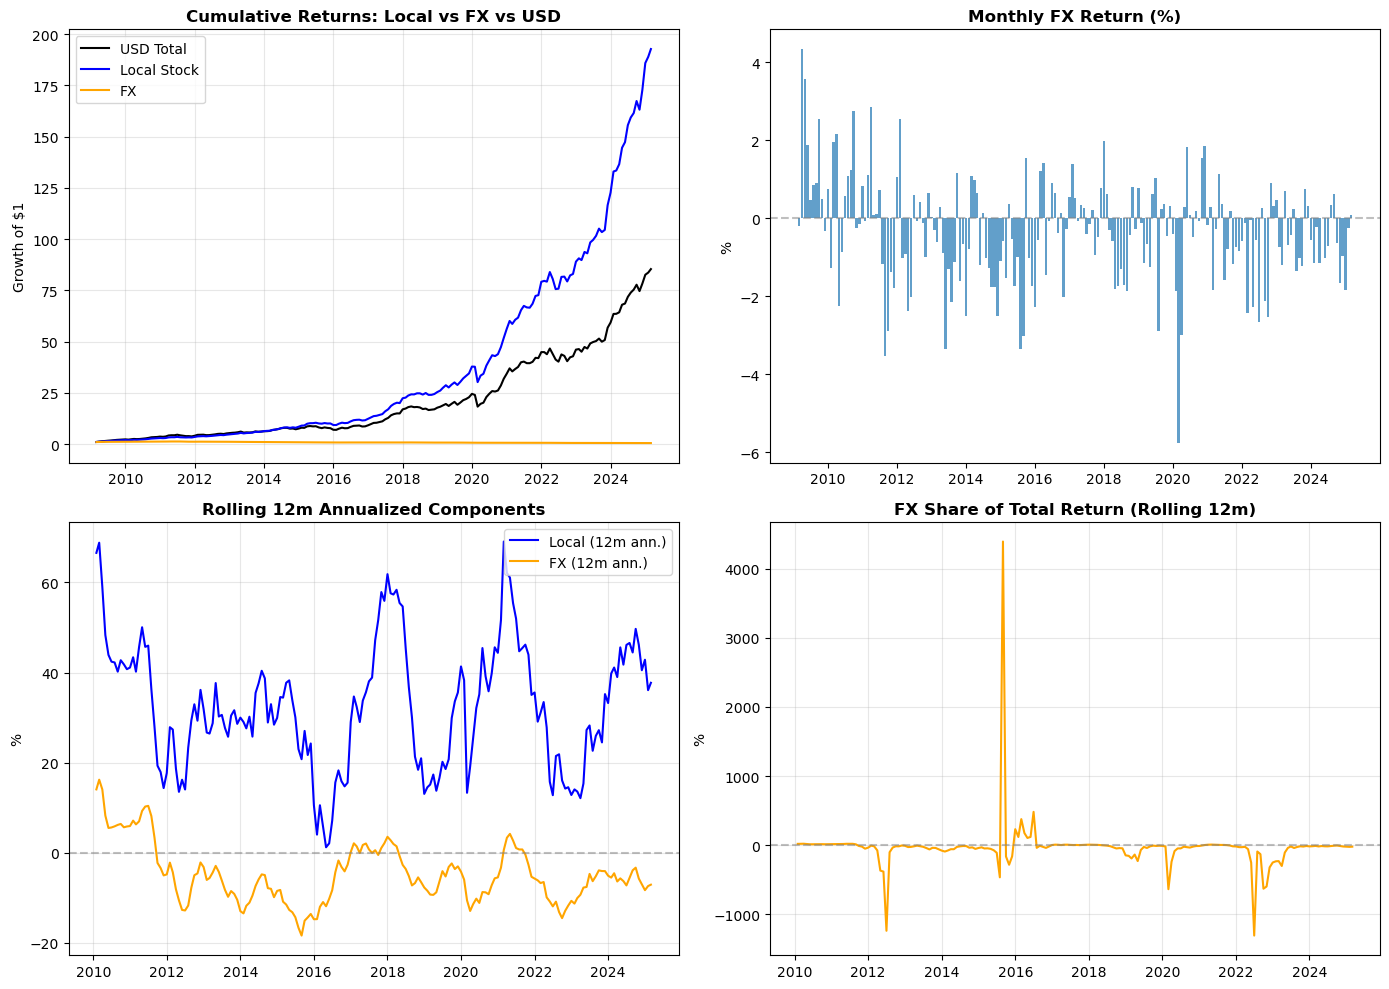

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
ax.plot((1+monthly['usd_ret']).cumprod(), lw=1.5, label='USD Total', color='black')
ax.plot((1+monthly['local_ret']).cumprod(), lw=1.5, label='Local Stock', color='blue')
ax.plot((1+monthly['fx_ret']).cumprod(), lw=1.5, label='FX', color='orange')
ax.set_title('Cumulative Returns: Local vs FX vs USD', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

ax = axes[0,1]
ax.bar(monthly.index, monthly['fx_ret']*100, width=25, alpha=0.7)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_title('Monthly FX Return (%)', fontweight='bold')
ax.set_ylabel('%')

ax = axes[1,0]
roll_local = monthly['local_ret'].rolling(12).mean()*12*100
roll_fx = monthly['fx_ret'].rolling(12).mean()*12*100
ax.plot(roll_local.index, roll_local, lw=1.5, label='Local (12m ann.)', color='blue')
ax.plot(roll_fx.index, roll_fx, lw=1.5, label='FX (12m ann.)', color='orange')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_title('Rolling 12m Annualized Components', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel('%')

ax = axes[1,1]
roll_share = monthly['fx_ret'].rolling(12).sum() / monthly['usd_ret'].rolling(12).sum() * 100
ax.plot(roll_share.index, roll_share, lw=1.5, color='orange')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_title('FX Share of Total Return (Rolling 12m)', fontweight='bold')
ax.set_ylabel('%'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb13_fx_decomposition_overview.pdf', bbox_inches='tight')
plt.show()


## 5. Annual FX Decomposition


      USD Return  Local Return  FX Return  Months
year                                             
2009       120.6          90.8       15.4    10.0
2010        57.8          48.4        5.8    12.0
2011         8.1          14.3       -5.1    12.0
2012        38.5          42.0       -2.3    12.0
2013        17.4          32.0      -10.1    12.0
2014        18.3          31.8       -9.6    12.0
2015         7.4          26.2      -12.9    12.0
2016        11.3          15.5       -2.8    12.0
2017        72.9          71.9        2.1    12.0
2018        13.5          22.1       -6.5    12.0
2019        34.7          41.1       -3.1    12.0
2020        39.3          50.0       -5.8    12.0
2021        31.7          40.4       -5.3    12.0
2022         2.1          14.2      -11.2    12.0
2023        32.5          40.4       -4.1    12.0
2024        37.9          48.2       -6.9    12.0
2025         9.0          11.5       -2.0     3.0


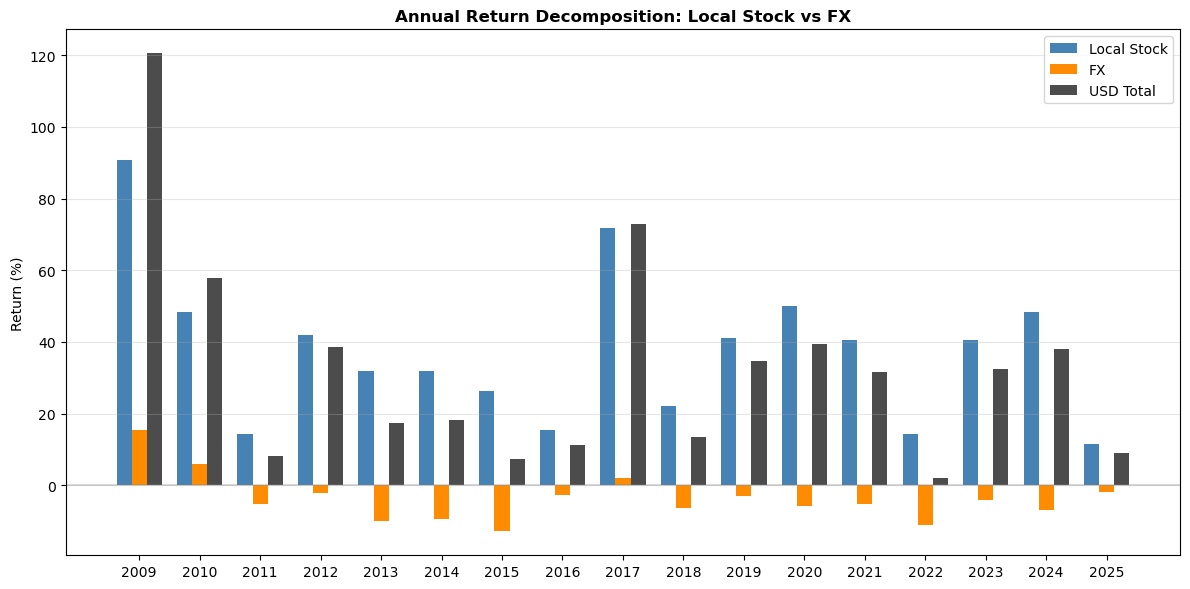

In [6]:
annual = monthly.groupby('year').apply(
    lambda g: pd.Series({
        'USD Return': ((1+g['usd_ret']).prod()-1)*100,
        'Local Return': ((1+g['local_ret']).prod()-1)*100,
        'FX Return': ((1+g['fx_ret']).prod()-1)*100,
        'Months': len(g)
    })
)
print(annual.to_string(float_format='%.1f'))

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(annual))
w = 0.25
ax.bar([i-w for i in x], annual['Local Return'], w, label='Local Stock', color='steelblue')
ax.bar([i for i in x], annual['FX Return'], w, label='FX', color='darkorange')
ax.bar([i+w for i in x], annual['USD Return'], w, label='USD Total', color='black', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(annual.index.astype(int))
ax.set_ylabel('Return (%)')
ax.set_title('Annual Return Decomposition: Local Stock vs FX', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='gray', ls='-', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb13_annual_fx_decomposition.pdf', bbox_inches='tight')
plt.show()


## 6. Country-Level FX Contribution


Country-Level FX Summary (Top 10):
                    avg_weight  avg_fx_contrib  fx_ann  avg_weight_pct
country                                                               
INDIA                    0.182          -0.001  -1.178          18.206
CHINA                    0.114          -0.000  -0.052          11.365
INDONESIA                0.088          -0.000  -0.364           8.831
SOUTH AFRICA             0.085          -0.000  -0.595           8.463
TAIWAN                   0.085          -0.000  -0.044           8.452
SOUTH KOREA              0.084           0.000   0.003           8.374
HONG KONG                0.058          -0.000  -0.006           5.773
BRAZIL                   0.057          -0.001  -0.759           5.742
THAILAND                 0.052          -0.000  -0.026           5.153
RUSSIAN FEDERATION       0.043          -0.000  -0.426           4.325


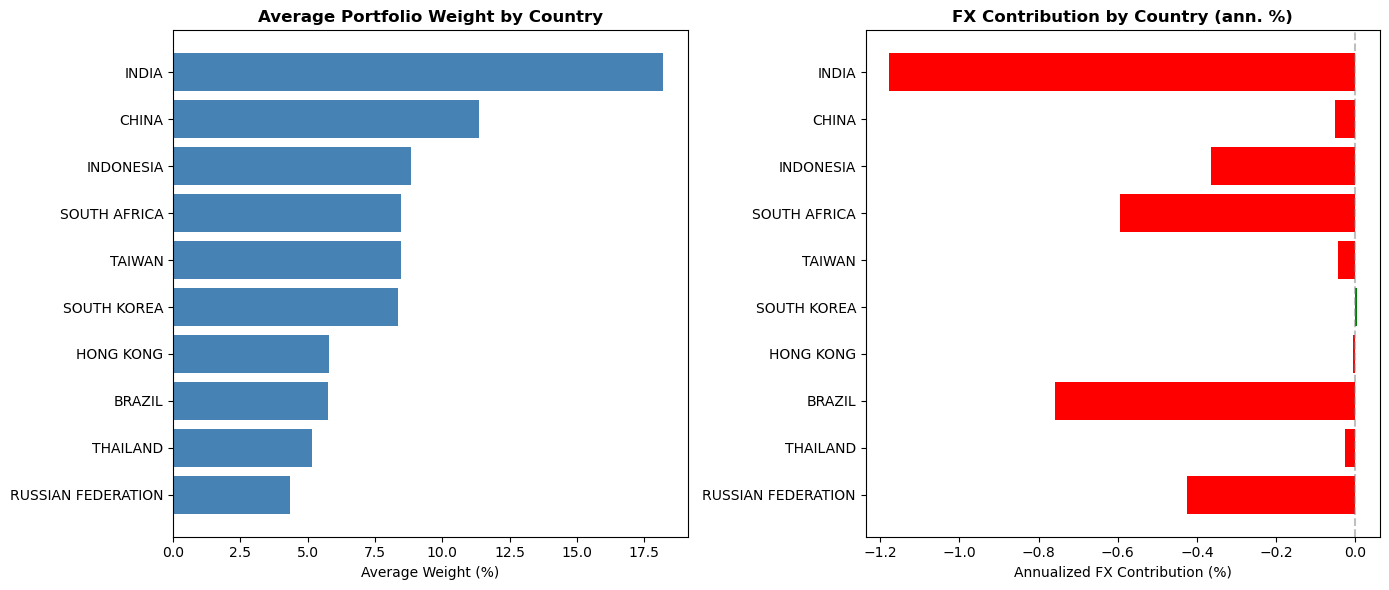

In [7]:
country_fx = h.groupby(['ym','country']).apply(
    lambda g: pd.Series({
        'weight': g['weight'].sum(),
        'fx_contrib': (g['fx_ret'] * g['weight']).sum(),
    })
).reset_index()

country_summary = country_fx.groupby('country').agg(
    avg_weight=('weight','mean'),
    avg_fx_contrib=('fx_contrib','mean'),
).sort_values('avg_weight', ascending=False)
country_summary['fx_ann'] = country_summary['avg_fx_contrib'] * 12 * 100
country_summary['avg_weight_pct'] = country_summary['avg_weight'] * 100

print('Country-Level FX Summary (Top 10):')
print(country_summary.head(10).to_string(float_format='%.3f'))

top10 = country_summary.head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.barh(range(len(top10)), top10['avg_weight_pct'], color='steelblue')
ax.set_yticks(range(len(top10))); ax.set_yticklabels(top10.index)
ax.set_xlabel('Average Weight (%)')
ax.set_title('Average Portfolio Weight by Country', fontweight='bold')
ax.invert_yaxis()

ax = axes[1]
colors = ['red' if v < 0 else 'green' for v in top10['fx_ann']]
ax.barh(range(len(top10)), top10['fx_ann'], color=colors)
ax.set_yticks(range(len(top10))); ax.set_yticklabels(top10.index)
ax.set_xlabel('Annualized FX Contribution (%)')
ax.set_title('FX Contribution by Country (ann. %)', fontweight='bold')
ax.invert_yaxis()
ax.axvline(0, color='gray', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb13_country_fx_analysis.pdf', bbox_inches='tight')
plt.show()


## 7. FX Impact on Hedged vs Unhedged


Correlation(Unhedged, FX): 0.506
Correlation(Hedged, FX): -0.006
Reduction: 99%


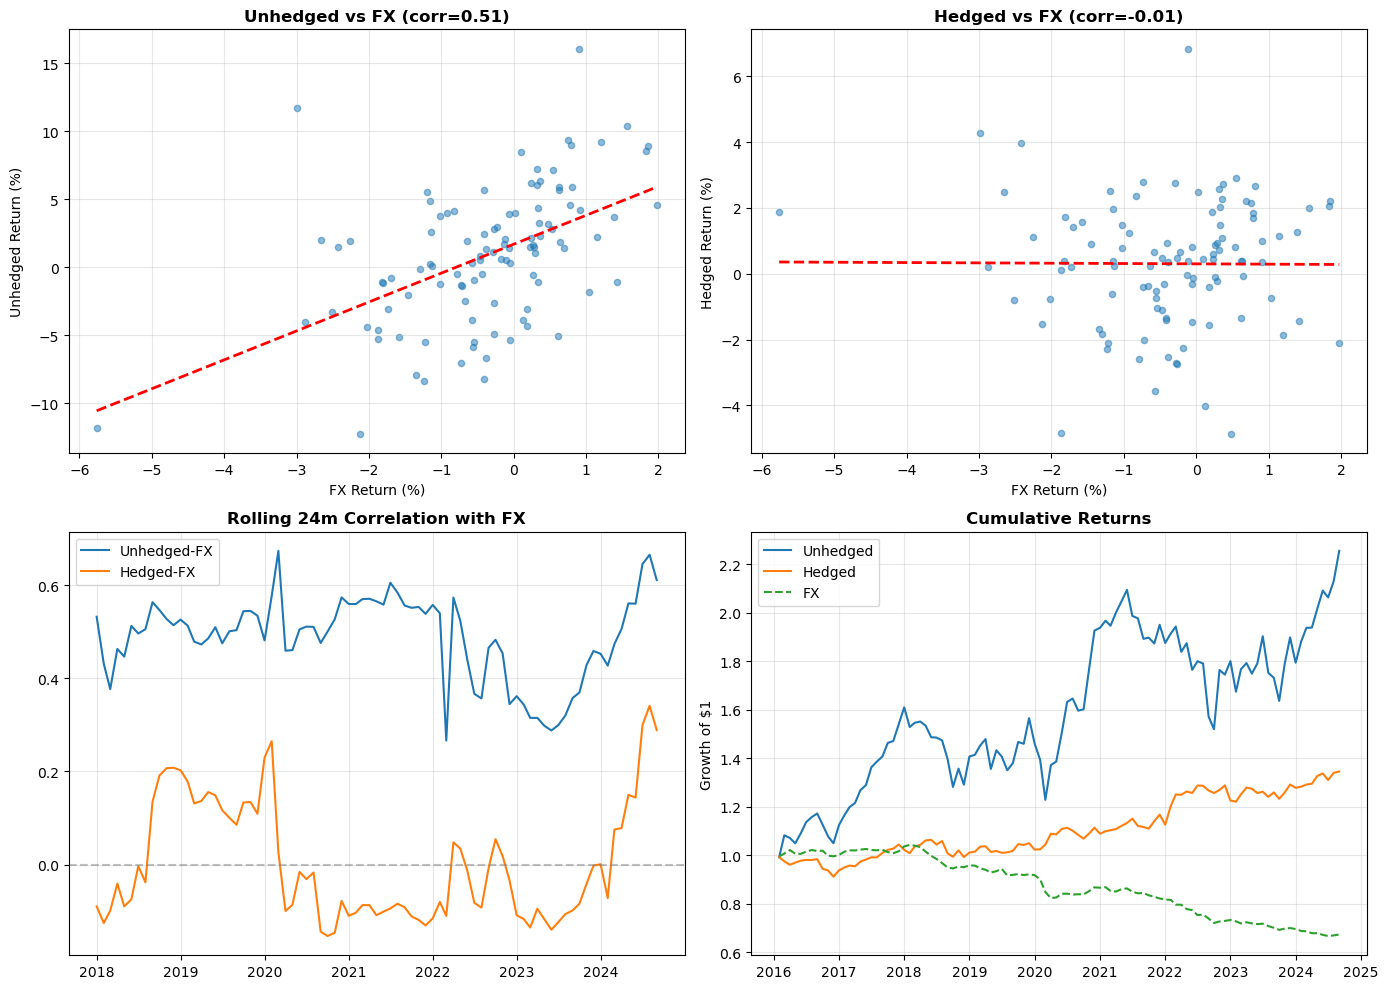

In [8]:
# Compute portfolio-level FX return and compare correlation with strategy returns
lo = hdf['A_long'].dropna()
hd = hdf['A_hedged_eem'].dropna()
port_fx = monthly['fx_ret']

aligned = pd.concat([lo, hd, port_fx], axis=1, keys=['unhedged','hedged','fx']).dropna()

corr_un = aligned['unhedged'].corr(aligned['fx'])
corr_hd = aligned['hedged'].corr(aligned['fx'])

print(f'Correlation(Unhedged, FX): {corr_un:.3f}')
print(f'Correlation(Hedged, FX): {corr_hd:.3f}')
print(f'Reduction: {(1 - abs(corr_hd)/abs(corr_un))*100:.0f}%')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
ax.scatter(aligned['fx']*100, aligned['unhedged']*100, alpha=0.5, s=20)
z = np.polyfit(aligned['fx'], aligned['unhedged'], 1)
x_line = np.linspace(aligned['fx'].min(), aligned['fx'].max(), 50)
ax.plot(x_line*100, np.polyval(z, x_line)*100, 'r--', lw=2)
ax.set_xlabel('FX Return (%)')
ax.set_ylabel('Unhedged Return (%)')
ax.set_title(f'Unhedged vs FX (corr={corr_un:.2f})', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[0,1]
ax.scatter(aligned['fx']*100, aligned['hedged']*100, alpha=0.5, s=20)
z = np.polyfit(aligned['fx'], aligned['hedged'], 1)
ax.plot(x_line*100, np.polyval(z, x_line)*100, 'r--', lw=2)
ax.set_xlabel('FX Return (%)')
ax.set_ylabel('Hedged Return (%)')
ax.set_title(f'Hedged vs FX (corr={corr_hd:.2f})', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1,0]
roll_corr_un = aligned['unhedged'].rolling(24).corr(aligned['fx'])
roll_corr_hd = aligned['hedged'].rolling(24).corr(aligned['fx'])
ax.plot(roll_corr_un.index, roll_corr_un, label='Unhedged-FX', lw=1.5)
ax.plot(roll_corr_hd.index, roll_corr_hd, label='Hedged-FX', lw=1.5)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_title('Rolling 24m Correlation with FX', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1,1]
ax.plot((1+aligned['unhedged']).cumprod(), label='Unhedged', lw=1.5)
ax.plot((1+aligned['hedged']).cumprod(), label='Hedged', lw=1.5)
ax.plot((1+aligned['fx']).cumprod(), label='FX', lw=1.5, ls='--')
ax.set_title('Cumulative Returns', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb13_fx_hedged_vs_unhedged.pdf', bbox_inches='tight')
plt.show()


## 8. Variance Decomposition and Summary


In [9]:
# Variance decomposition
var_local = monthly['local_ret'].var()
var_fx = monthly['fx_ret'].var()
cov_lf = 2 * monthly['local_ret'].cov(monthly['fx_ret'])
var_total = monthly['usd_ret'].var()

print('=== VARIANCE DECOMPOSITION ===')
print(f'Var(Local) = {var_local/var_total*100:.1f}% of total variance')
print(f'Var(FX) = {var_fx/var_total*100:.1f}% of total variance')
print(f'2*Cov(Local,FX) = {cov_lf/var_total*100:.1f}% of total variance')
print(f'FX adds {(var_fx+cov_lf)/var_total*100:.1f}% to portfolio variance')
print(f'Local vol (ann): {monthly["local_ret"].std()*np.sqrt(12)*100:.1f}%')
print(f'USD vol (ann): {monthly["usd_ret"].std()*np.sqrt(12)*100:.1f}%')

# Save outputs
monthly.to_csv(f'{OUTPUT_DIR}/csv/nb13_fx_decomposition_monthly.csv')
annual.to_csv(f'{OUTPUT_DIR}/csv/nb13_fx_decomposition_annual.csv')
country_summary.to_csv(f'{OUTPUT_DIR}/csv/nb13_country_fx_summary.csv')
print('\nSaved: nb13_fx_decomposition_monthly.csv, nb13_fx_decomposition_annual.csv, nb13_country_fx_summary.csv')


=== VARIANCE DECOMPOSITION ===
Var(Local) = 66.3% of total variance
Var(FX) = 7.4% of total variance
2*Cov(Local,FX) = 28.3% of total variance
FX adds 35.7% to portfolio variance
Local vol (ann): 14.3%
USD vol (ann): 17.6%

Saved: nb13_fx_decomposition_monthly.csv, nb13_fx_decomposition_annual.csv, nb13_country_fx_summary.csv
